# Colmeia Visualization (Notebook)

Notebook para carregar o CSV consolidado, filtrar casas e gerar grafico de dispersao com escala log-log (preco vs area).

In [1]:
from pathlib import Path
import pandas as pd

try:
    from plotnine import (
        ggplot, aes, geom_point, scale_x_log10, scale_y_log10, labs, theme_bw
    )
except Exception as exc:
    raise ImportError(
        "Pacote 'plotnine' nao encontrado. Instale com: pip install plotnine"
    ) from exc

In [ ]:
# Configuracao
CSV_DIR = Path('../data/processed/csv')
CSV_PATTERN = 'colmeia_*.csv'

def find_latest_csv(csv_dir: Path = CSV_DIR, pattern: str = CSV_PATTERN) -> Path:
    files = sorted(csv_dir.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f'Nenhum CSV encontrado em: {csv_dir.resolve()}')
    return files[-1]

def load_csv(csv_file: Path) -> pd.DataFrame:
    if not csv_file.exists():
        raise FileNotFoundError(f'Arquivo CSV nao encontrado: {csv_file}')
    return pd.read_csv(csv_file, sep=';')

In [ ]:
# Se quiser forcar um arquivo especifico, descomente e ajuste:
# csv_file = Path('../data/processed/csv/colmeia_venda_2026-05-15.csv')

csv_file = find_latest_csv()
df = load_csv(csv_file)

print(f'CSV selecionado: {csv_file.resolve()}')
print(f'Linhas no CSV: {len(df)}')
df.head()

CSV selecionado: /home/walmes/Projects/UFPR_GenAI/DSLLM-02-web-scraping/output_csv/colmeia/colmeia_venda_2026-05-15.csv
Linhas no CSV: 324


,id,valor_raw,titulo,local,desc,dorm,suite,banheiro,garagem,area_terr,area_const,valor,arquivo_html
0,3220,"R$ 250.000,00 V",APARTAMENTO À VENDA EM DOURADOS/MS,Jardim Maringá - Dourados/MS,Apartamento térreo semi mobiliado à venda no R...,2.0,NaN,1.0,1.0,NaN,NaN,250000.0,colmeia_2026-05-15_venda_001.html
1,3219,"R$ 450.000,00 V",CASA À VENDA EM DOURADOS/MS,Jardim Água Boa - Dourados/MS,"Localizada próxima à Rua Hayel Bon Faker, esta...",4.0,1.0,3.0,2.0,NaN,NaN,450000.0,colmeia_2026-05-15_venda_001.html
2,3218,"R$ 950.000,00 V",CASA À VENDA EM DOURADOS/MS,Jardim Itaipú - Dourados/MS,"Localizada em um dos bairros nobres da cidade,...",3.0,1.0,3.0,2.0,NaN,NaN,950000.0,colmeia_2026-05-15_venda_001.html
3,3208,"R$ 230.000,00 V",CASA À VENDA EM DOURADOS/MS,Vila Toscana II - Dourados/MS,Casa à venda na Vila Toscana! Apta a financiam...,2.0,NaN,1.0,1.0,180.0,NaN,230000.0,colmeia_2026-05-15_venda_001.html
4,3207,"R$ 150.000,00 V",APARTAMENTO À VENDA EM DOURADOS/MS,Chácaras Trevo - Dourados/MS,Apartamento à venda no Residencial Itajubá I! ...,2.0,NaN,1.0,1.0,NaN,NaN,150000.0,colmeia_2026-05-15_venda_001.html


In [4]:
# Filtro: apenas casas
casas = df[df['titulo'].str.contains('casa', case=False, na=False)].copy()

# Area para plot: prioriza area construida e usa area do terreno como fallback
casas['area_plot'] = casas['area_const'].fillna(casas['area_terr'])

# Remocao de valores invalidos para escala log
casas = casas[(casas['valor'].notna()) & (casas['area_plot'].notna())]
casas = casas[(casas['valor'] > 0) & (casas['area_plot'] > 0)]

print(f'Linhas de casas para plot: {len(casas)}')
casas[['titulo', 'valor', 'area_plot']].head()

Linhas de casas para plot: 69


,titulo,valor,area_plot
3,CASA À VENDA EM DOURADOS/MS,230000.0,180.0
7,CASA À VENDA EM DOURADOS/MS,260000.0,157.0
9,CASA À VENDA EM DOURADOS/MS,390000.0,220.0
14,CASA À VENDA EM DOURADOS/MS,350000.0,220.0
16,CASA À VENDA NO PORTO MADERO EM DOURADOS/MS,1700000.0,300.0


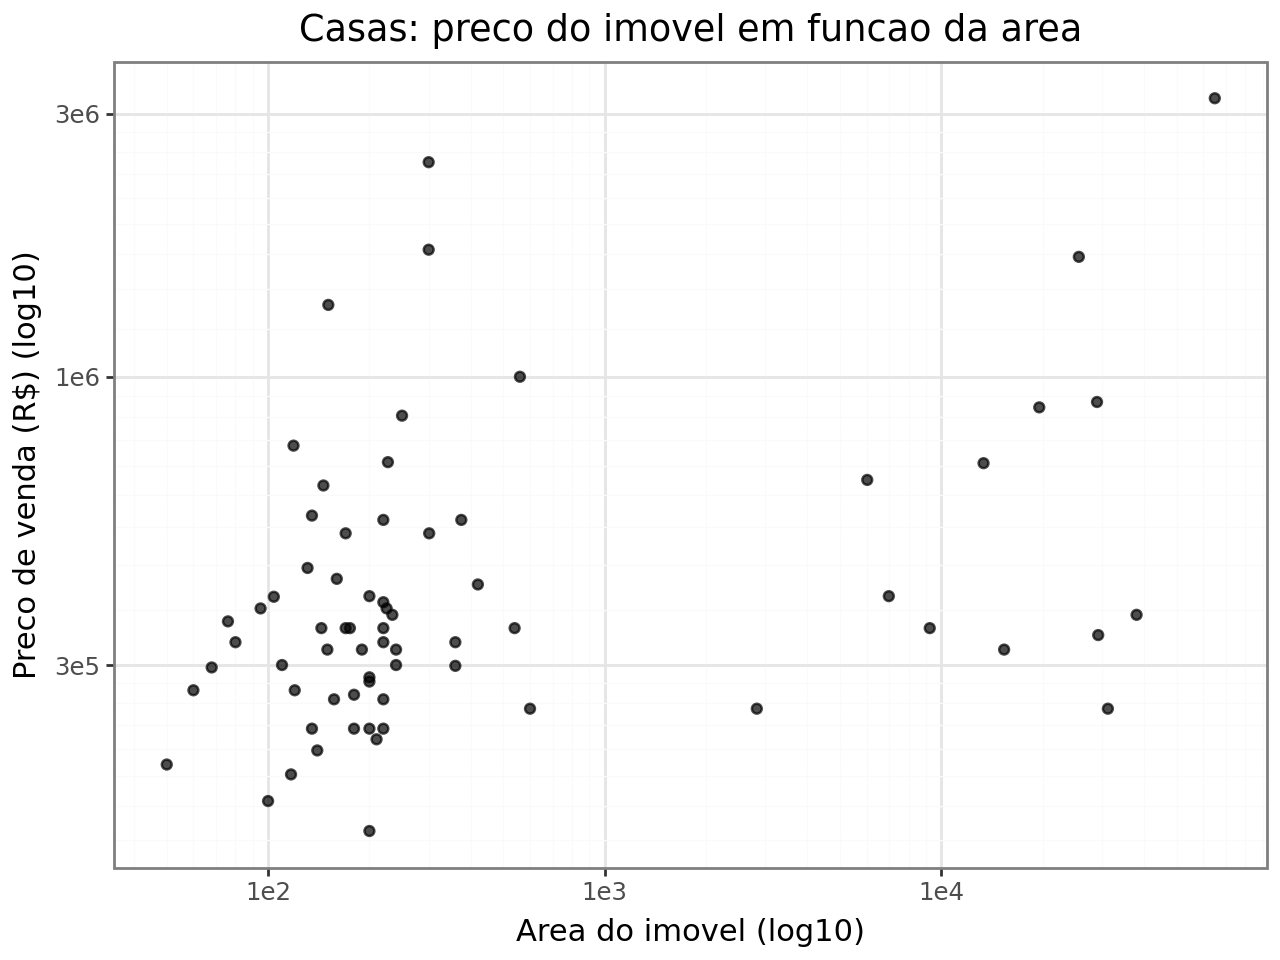

In [5]:
if casas.empty:
    raise RuntimeError('Nao ha dados de casas com valor e area positivos para gerar o grafico.')

plot_obj = (
    ggplot(casas, aes(x='area_plot', y='valor'))
    + geom_point(alpha=0.7)
    + scale_x_log10()
    + scale_y_log10()
    + labs(
        title='Casas: preco do imovel em funcao da area',
        x='Area do imovel (log10)',
        y='Preco de venda (R$) (log10)'
    )
    + theme_bw()
)

plot_obj